# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

#### Keys to Analyze:

Continue from Week 4, I wanted to learn more about:

- Principal job related to the highest degree

- Loan amount to complete Undergraduate Degrees

For this week, I'll analyze these:

- Extent job related to highest degree 

- Field of study (STEM vs non-STEM classification) 

- Current occupation code (can validate against field)

- Total amount borrowed for undergraduate degree

- Current earnings

- Separate STEM who stay vs. leave

#### Questions to answer (Continue from Week 4 HW)

- Question 5: To what extent do STEM graduates actually work in STEM fields?

- Question 6: Do STEM graduates who leave STEM fields earn enough to justify their educational investment?

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

D:\Users\Dustin\AppData\Local\Temp\ipykernel_13080\2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

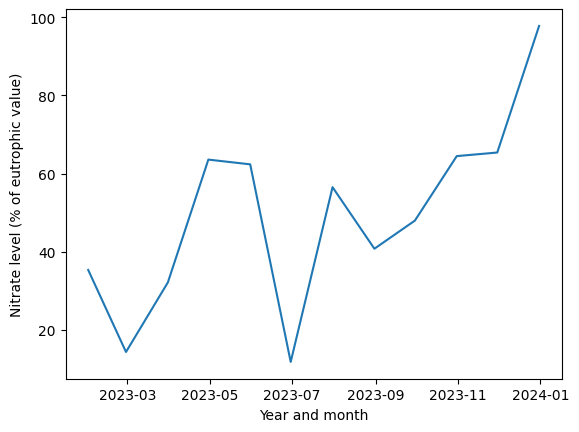

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

D:\Users\Dustin\AppData\Local\Temp\ipykernel_13080\1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

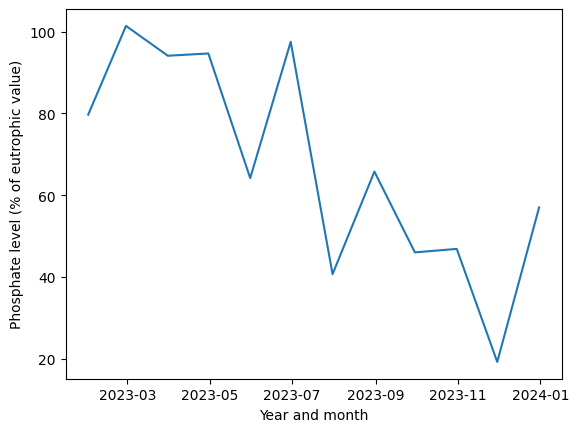

In [4]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

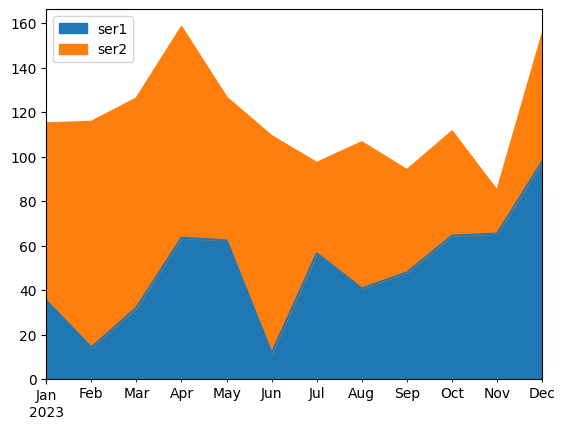

In [5]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

#### Advantages of Area Plot:
- Shows cumulative effect: We can see both at the same time without scrolling up and down

- Easier to understand: We can see which months the nitrate and phosphate level are high/low at once

- Space efficient: Save space and still convey the message

#### Disadvantages of Area Plot:
- Hard to read exact values - Can't easily determine individual nutrient levels

- Misleading interpretation - At the first glance, I thought ser2 is for Nitrate, since it's on top

- Hard to see individual trends: Which one is for Nitrate/phosphate? Can't really tell

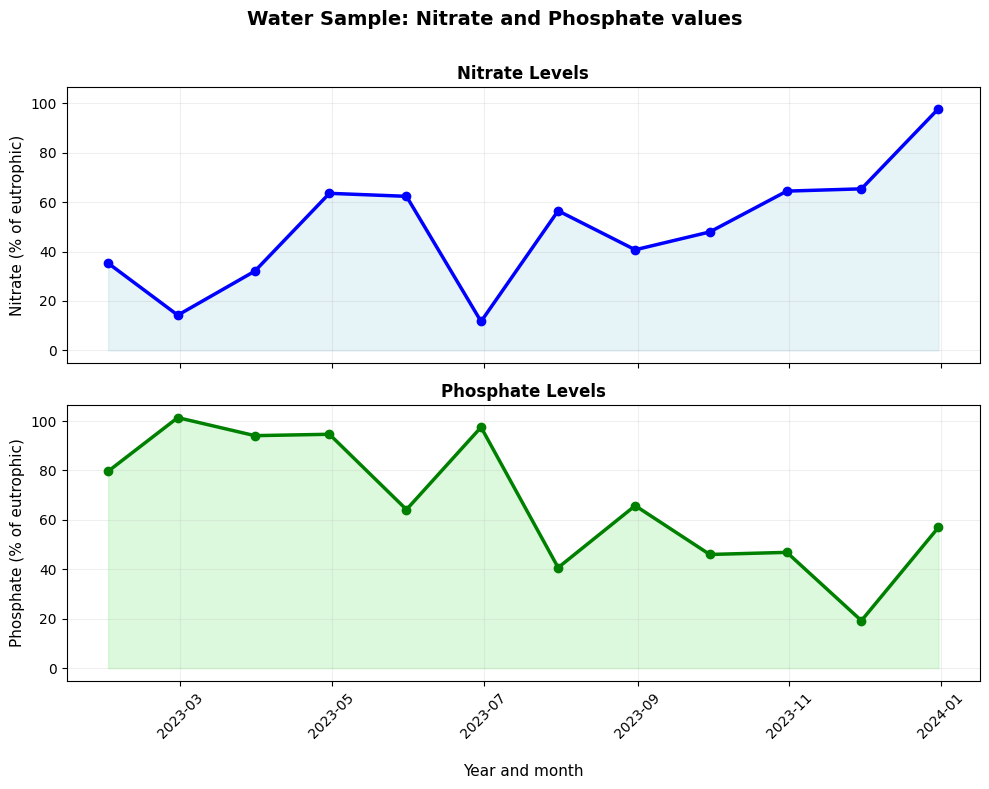

In [6]:
# Improve for this area plot using pyplot.

# Combine 2 subplots in one plot
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)

# Nitrate (On top) and add labels
axes[0].plot(datearray, time_series, 'b-', linewidth=2.5, marker='o')
axes[0].fill_between(datearray, 0, time_series, alpha=0.3, color='lightblue')
axes[0].set_ylabel("Nitrate (% of eutrophic)", fontsize=11)
axes[0].set_title("Nitrate Levels", fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.2)

# Phosphate (On bottom) and add labels
axes[1].plot(datearray, time_series_2, 'g-', linewidth=2.5, marker='o')
axes[1].fill_between(datearray, 0, time_series_2, alpha=0.3, color='lightgreen')
axes[1].set_xlabel("\nYear and month", fontsize=11)
axes[1].set_ylabel("Phosphate (% of eutrophic)", fontsize=11)
axes[1].set_title("Phosphate Levels", fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.2)

# Add chart title
plt.xticks(rotation=45)
plt.suptitle("Water Sample: Nitrate and Phosphate values\n", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [7]:
# Code copy from HW2 here for this week analysis

# Load epcg23 and Dpcg23 for column lookup
df = pd.read_csv('epcg23.zip')
dict_df = pd.read_csv('Dpcg23.csv')

# Function to lookup column information
def lookup_col(col_name):

    result = dict_df[dict_df['SAS_NAME'] == col_name.upper()]
    if len(result) > 0:
        row = result.iloc[0]
        print(f"\nColumn Name: {col_name}")
        print(f"Description: {row['DESCRIPTION']}")
        print(f"Domain: {row['DOMAIN']}")
        print(f"Question: {row['QUESTION']}")
        
    else:
        print(f"Column '{col_name}' not found")

# Identify the invalid max values
invalid_mask = df['EARN'] >= 9999990  # Values close to 10 million

# Remove them
df_clean = df[~invalid_mask].copy()

# Clean high outliers by capping at the 99th percentile
earnings_99th = df_clean['EARN'].quantile(0.99)

# remove values above the 99th percentile
df_clean_99 = df_clean[df_clean['EARN'] <= earnings_99th].copy()

# Load the major codes file to determine STEM vs non-STEM majors
majors_df = pd.read_csv('N2BAMED.csv')

D:\Users\Dustin\AppData\Local\Temp\ipykernel_13080\2209463886.py:4: DtypeWarning: Columns (231,232,233,234,235,236,237,238,239) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('epcg23.zip')


In [8]:
# Code copy from HW4 here for this week analysis

# Categorical variables using the major codes from N2BAMED.csv

# 1. Create STEM classification in majors_df
# These are common keywords that often indicate a STEM field. 
# Defined by the National Science Foundation and other organizations.

stem_keywords = [
    'computer', 'information', 'engineering', 'mathematics', 'statistics',
    'physics', 'chemistry', 'biology', 'biochemistry', 'neuroscience',
    'astronomy', 'geology', 'environmental science', 'materials science',
    'applied mathematics', 'operations research', 'data science', 'science',
    'technology', 'mechanical', 'electrical', 'civil', 'chemical', 'aerospace'
]

# Determine if a field description is STEM based on keywords
def is_stem_field(desc):    
    if pd.isna(desc):
        return 0
    desc_lower = str(desc).lower()
    for keyword in stem_keywords:
        if keyword in desc_lower:
            return 1
    return 0

majors_df['is_stem'] = majors_df['Description'].apply(is_stem_field)

# 2. Create mapping dictionaries
major_to_stem = dict(zip(majors_df['Value'], majors_df['is_stem']))
major_to_desc = dict(zip(majors_df['Value'], majors_df['Description']))

# 3. Apply to main dataset
df_final = df_clean_99.copy()

# Map using N2BAMED column
df_final['is_stem_major'] = df_final['N2BAMED'].map(major_to_stem)
df_final['major_desc'] = df_final['N2BAMED'].map(major_to_desc)

# 4. Check merge results
mapped = df_final['is_stem_major'].notna().sum()
total = len(df_final)

if mapped > 0:
    stem_count = df_final['is_stem_major'].sum()

# 5. Create analysis variables
df_final['total_debt'] = df_final['UGLOANR'] + df_final['GRLOANR'].fillna(0)

# Filter to recent graduates (last 10 years)
recent_year = df_final['BAYR'].max() - 10
df_recent = df_final[df_final['BAYR'] >= recent_year].copy()

# 6. Create cohorts
df_recent['cohort'] = pd.cut(
    df_recent['BAYR'],
    bins=[2013, 2015, 2017, 2019, 2021, 2023],
    labels=['2013-15', '2015-17', '2017-19', '2019-21', '2021-23']
)

In [9]:
# Week 6 HW variables look up
# Show some descriptions for this week analysis

lookup_col('OCEDRLP') # To what extent was your work on your principal job related to your highest degree?
lookup_col('N2BAMED') # What is the major field of study for your first BA degree? (best code)
lookup_col('UGLOANR') # Completed Undergraduate Degrees- Total amount borrowed
lookup_col('SALARY') # what was your basic annual salary on your principal job, before deductions?
lookup_col('EARN') # what was your total earned income for 2020, before deductions?

# Some reasons for not working in STEM
lookup_col('NRPAY')  # pay/promotion
lookup_col('NRCON')  # working conditions
lookup_col('NRLOC')  # job location
lookup_col('NRCHG')  # career change
lookup_col('NRFAM')  # family-related reasons
lookup_col('NROCNA') # suitable job not available


Column Name: OCEDRLP
Description: Extent that principal job is related to highest degree
Domain: Working during the week of February 1, 2023
Question: To what extent was your work on your principal job related to your highest degree?

Column Name: N2BAMED
Description: Field of study of for first bachelor's degree - best code
Domain: All respondents
Question: What is the major field of study for your first BA degree? (best code)

Column Name: UGLOANR
Description: Amount borrowed to finance UNDERGRADUATE degree(s)
Domain: All respondents
Question: Completed Undergraduate Degrees- Total amount borrowed

Column Name: SALARY
Description: Salary (annualized)
Domain: Working during the week of February 1, 2023
Question: As of the week of February 1, 2023, what was your basic annual salary on your principal job, before deductions?

Column Name: EARN
Description: Total earned income before deductions in previous year
Domain: Worked during calendar year 2020
Question: Counting all jobs held in 

In [10]:
# Values for OCEDRLP (To what extent was your work on your principal job related to your highest degree?) are 1, 2, 3, L
# 1: Closely relate
# 2: Somewhat relate
# 3: Not relate
# L: Skip

# Convert to string first, then check
df_final['oc_str'] = df_final['OCEDRLP'].astype(str).str.strip()
df_final['working_in_stem_field'] = df_final['oc_str'].isin(['1', '2'])

# Drop the temporary column
df_final = df_final.drop('oc_str', axis=1)

# Identify STEM graduates
stem_grads = df_final[df_final['is_stem_major'] == 1].copy()
stem_in_stem = stem_grads[stem_grads['working_in_stem_field'] == True]
stem_leavers = stem_grads[stem_grads['working_in_stem_field'] == False]

print("STEM GRADUATE OUTCOMES:\n")
print(f"Total STEM graduates: {len(stem_grads):,}")
print(f"STEM graduates working in STEM: {len(stem_in_stem):,} ({len(stem_in_stem)/len(stem_grads)*100:.1f}%)")
print(f"STEM graduates NOT in STEM: {len(stem_leavers):,} ({len(stem_leavers)/len(stem_grads)*100:.1f}%)")

STEM GRADUATE OUTCOMES:

Total STEM graduates: 44,425
STEM graduates working in STEM: 37,839 (85.2%)
STEM graduates NOT in STEM: 6,586 (14.8%)


WHY STEM GRADUATES LEAVE STEM FIELDS:

            Reason  Count  Pct_of_Leavers
     Pay/Promotion   2469       37.488612
Working Conditions   2467       37.458245
   Location Change   2344       35.590647
     Career Change   2230       33.859702
 Job Not Available   1319       20.027331
    Family Reasons   1142       17.339812


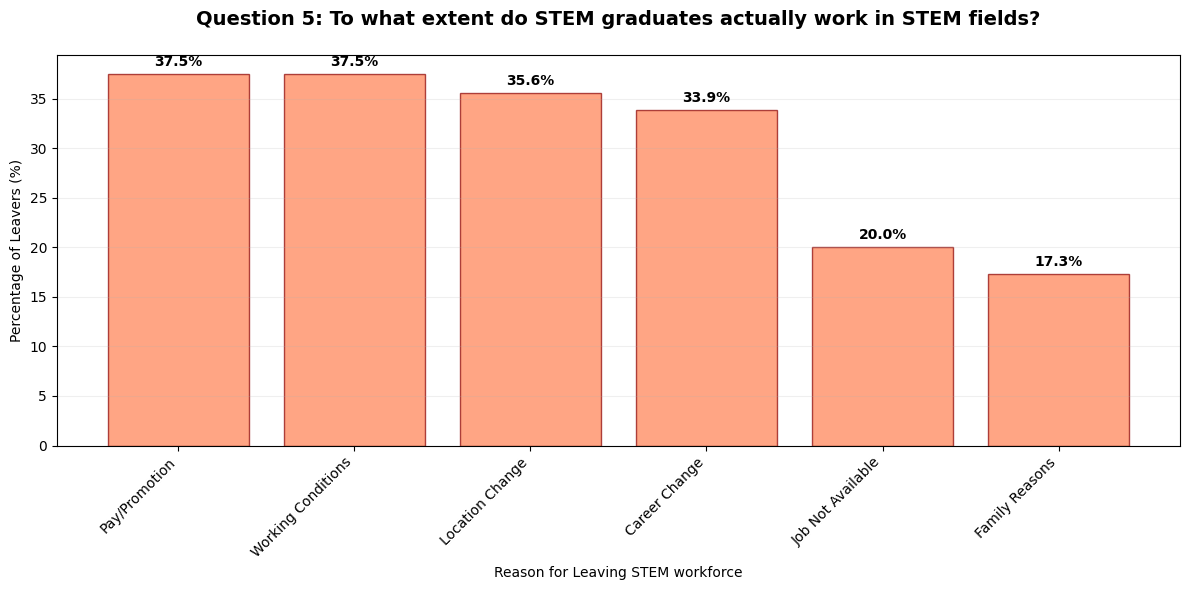

In [11]:
# Chart to show the reason for STEM not working in STEM

# Reason for those that left the field of study
if len(stem_leavers) > 0:
    
    # Define reason variables
    reason_vars = {
        'NRPAY': 'Pay/Promotion',
        'NRCON': 'Working Conditions',
        'NRLOC': 'Location Change',
        'NRCHG': 'Career Change',
        'NRFAM': 'Family Reasons',
        'NROCNA': 'Job Not Available'
    }
    
    # Check which exist
    available_reasons = {}
    for var, label in reason_vars.items():
        if var in stem_leavers.columns:
            available_reasons[var] = label
    
    # Function to count 'Y' responses
    def count_positive(series):
        if series.dtype == 'object':
            # For string columns, count 'Y'
            return series.astype(str).str.upper().str.strip().eq('Y').sum()
        else:
            # For numeric columns, count 1
            return (series == 1).sum()
    
    # Calculate counts
    reason_counts = []
    for var, label in available_reasons.items():
        count = count_positive(stem_leavers[var])
        pct_of_leavers = (count / len(stem_leavers)) * 100 if len(stem_leavers) > 0 else 0
        
        reason_counts.append({
            'Reason': label,
            'Count': count,
            'Pct_of_Leavers': pct_of_leavers
        })
    
    reasons_df = pd.DataFrame(reason_counts).sort_values('Count', ascending=False)
    
    print("WHY STEM GRADUATES LEAVE STEM FIELDS:\n")
    print(reasons_df.to_string(index=False))
    
    # Create visualization
    if len(reasons_df) > 0 and reasons_df['Count'].sum() > 0:
        plt.figure(figsize=(12, 6))
        bars = plt.bar(reasons_df['Reason'], reasons_df['Pct_of_Leavers'], 
                       color='coral', edgecolor='darkred', alpha=0.7)
        plt.xlabel('Reason for Leaving STEM workforce')
        plt.ylabel('Percentage of Leavers (%)')
        plt.title('Question 5: To what extent do STEM graduates actually work in STEM fields?\n', fontsize=14, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        
        for bar, pct in zip(bars, reasons_df['Pct_of_Leavers']):
            plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                     f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')
        
        plt.grid(True, alpha=0.2, axis='y')
        plt.tight_layout()
        plt.show()
        
else:
    print("No STEM leavers found to analyze")

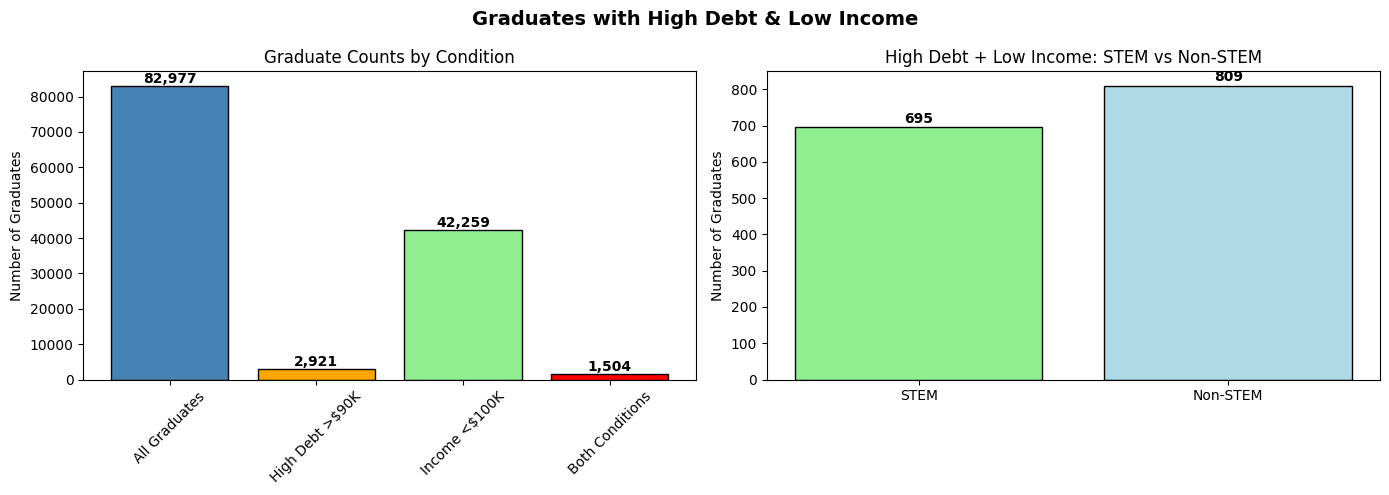

In [12]:
# Base on the number provided in Ppcg23.pdf for variable UGLOANR (Completed Undergraduate Degrees- Total amount borrowed)

# Map the field code in UGLOANR column
ugloanr_mapping = {
    1: 0,        # Did not earn degree
    2: 0,        # $0 debt
    3: 5000,     # 1-10k
    4: 15000,    # 10-20k
    5: 25000,    # 20-30k
    6: 35000,    # 30-40k
    7: 45000,    # 40-50k
    8: 55000,    # 50-60k
    9: 65000,    # 60-70k
    10: 75000,   # 70-80k
    11: 85000,   # 80-90k
    12: 100000   # 90k or more
}

# Apply mapping
df_final['UGLOANR_amount'] = df_final['UGLOANR'].map(ugloanr_mapping)

# Define income column
income_col = 'SALARY' if 'SALARY' in df_final.columns else 'EARN'

# Define the conditions
high_debt_condition = df_final['UGLOANR'] == 12
low_income_condition = df_final[income_col] < 100000

# Find graduates meeting high debt low income condition
high_debt_low_income = df_final[high_debt_condition & low_income_condition].copy()
stem_high_debt_low_income = high_debt_low_income[high_debt_low_income['is_stem_major'] == 1]
nonstem_high_debt_low_income = high_debt_low_income[high_debt_low_income['is_stem_major'] == 0]

# Create a bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Count comparison
categories = ['All Graduates', 'High Debt >$90K', 'Income <$100K', 'Both Conditions']
counts = [
    len(df_final),
    high_debt_condition.sum(),
    low_income_condition.sum(),
    len(high_debt_low_income)
]
colors = ['steelblue', 'orange', 'lightgreen', 'red']

bars1 = ax1.bar(categories, counts, color=colors, edgecolor='black')
ax1.set_ylabel('Number of Graduates')
ax1.set_title('Graduate Counts by Condition')
ax1.tick_params(axis='x', rotation=45)

# Add value labels
for bar, count in zip(bars1, counts):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Chart 2: STEM vs Non-STEM breakdown
if 'is_stem_major' in high_debt_low_income.columns:
    stem_counts = [
        len(stem_high_debt_low_income),
        len(nonstem_high_debt_low_income)
    ]
    bars2 = ax2.bar(['STEM', 'Non-STEM'], stem_counts, 
                    color=['lightgreen', 'lightblue'], edgecolor='black')
    ax2.set_ylabel('Number of Graduates')
    ax2.set_title('High Debt + Low Income: STEM vs Non-STEM')
    
    for bar, count in zip(bars2, stem_counts):
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Graduates with High Debt & Low Income', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

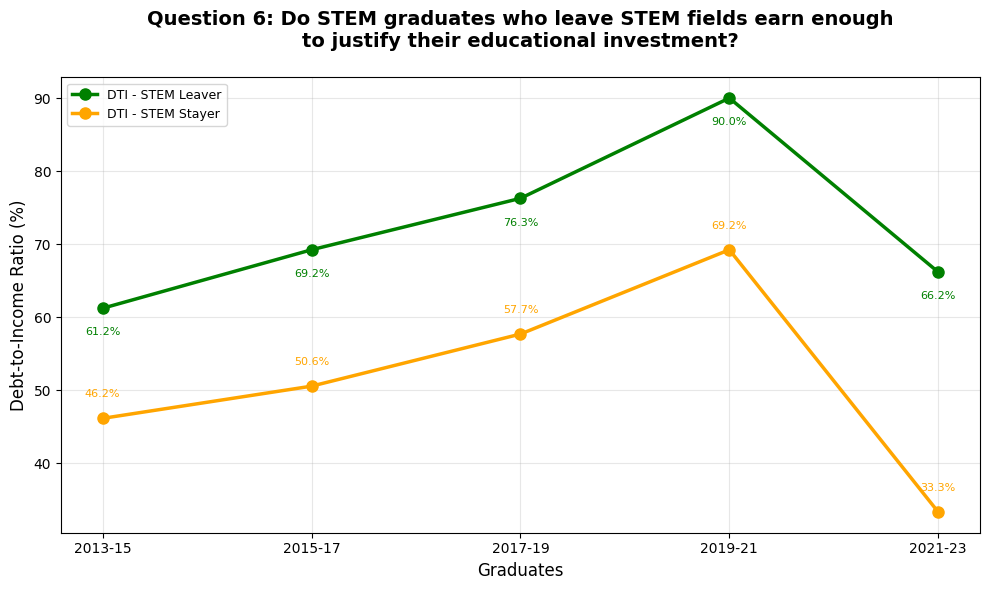

In [13]:
# Putting things together. Analyze Debt to Income level

# Data from Week 4 analysis
# This week STEM Leaver = NON-STEM.
cohort_data = pd.DataFrame({
    'Cohort': ['2013-15', '2015-17', '2017-19', '2019-21', '2021-23'],
    'STEM_Stayer_Salary': [97500, 89000, 78000, 65000, 135004],
    'STEM_Leaver_Salary': [73500, 65000, 59000, 50000, 68000],
})

# Let's just assume average debt of $45,000 (based on numer 1-12)
avg_debt = 45000

# Calculate metrics. 
# DTI Debt to Income 
cohort_data['DTI_Leaver'] = (avg_debt / cohort_data['STEM_Leaver_Salary']) * 100
cohort_data['DTI_Stayer'] = (avg_debt / cohort_data['STEM_Stayer_Salary']) * 100

# Create the line chart
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot DTI on left y-axis
ax1.plot(cohort_data['Cohort'], cohort_data['DTI_Leaver'], 
         marker='o', linewidth=2.5, markersize=8, color='green', 
         label='DTI - STEM Leaver')
ax1.plot(cohort_data['Cohort'], cohort_data['DTI_Stayer'], 
         marker='o', linewidth=2.5, markersize=8, color='orange', 
         label='DTI - STEM Stayer')
ax1.set_xlabel('Graduates', fontsize=12)
ax1.set_ylabel('Debt-to-Income Ratio (%)', fontsize=12, color='black')
ax1.tick_params(axis='y')
ax1.grid(True, alpha=0.3)

# Add title and legend
plt.title('Question 6: Do STEM graduates who leave STEM fields earn enough\nto justify their educational investment?\n', 
          fontsize=14, fontweight='bold')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

# Add value labels on points
for i, row in cohort_data.iterrows():
    ax1.annotate(f'{row["DTI_Leaver"]:.1f}%', 
                xy=(i, row['DTI_Leaver']), 
                xytext=(i, row['DTI_Leaver']-4),
                ha='center', va='bottom', fontsize=8, color='green')
    ax1.annotate(f'{row["DTI_Stayer"]:.1f}%', 
                xy=(i, row['DTI_Stayer']), 
                xytext=(i, row['DTI_Stayer']+4),
                ha='center', va='top', fontsize=8, color='orange')

plt.tight_layout()
plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

D:\Users\Dustin\AppData\Local\Temp\ipykernel_13080\924805265.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(Months, Received, 'b-', linewidth=2.5, marker='o', label='Received', color='teal')
D:\Users\Dustin\AppData\Local\Temp\ipykernel_13080\924805265.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g-" (-> color='g'). The keyword argument will take precedence.
  plt.plot(Months, Processed, 'g-', linewidth=2.5, marker='o', label='Processed', color='darkblue')


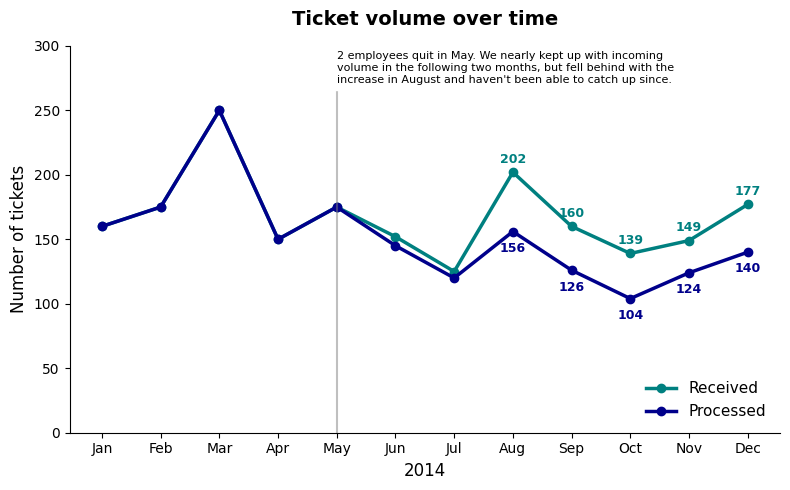

In [15]:
# I choose Figure 5.9 for this week

# Data
Months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
Processed = [160, 175, 250, 150, 175, 145, 120, 156, 126, 104, 124, 140]
Received = [160, 175, 250, 150, 175, 152, 125, 202, 160, 139, 149, 177]

# Create the plot
plt.figure(figsize=(8, 5))

# Plot both lines
plt.plot(Months, Received, 'b-', linewidth=2.5, marker='o', label='Received', color='teal')
plt.plot(Months, Processed, 'g-', linewidth=2.5, marker='o', label='Processed', color='darkblue')

# Plot the avhline
plt.axvline(x=4, color="gray", alpha=0.5)

# Add text block above the line
text_block = "2 employees quit in May. We nearly kept up with incoming\n" \
"volume in the following two months, but fell behind with the\n" \
"increase in August and haven't been able to catch up since."
plt.text(4, 270, text_block, fontsize=8, color='black', bbox=dict(facecolor='white', edgecolor='white'),        
         verticalalignment='bottom', horizontalalignment='left')

# Add numbers for August and later using a for loop
for i in range(len(Months)):
    if i >= 7:  # August is index 7
        # Add received number
        plt.text(i, Received[i] + 5, f'{Received[i]}', 
                 ha='center', va='bottom', fontsize=9, color='teal', fontweight='bold')
        # Add processed number
        plt.text(i, Processed[i] - 8, f'{Processed[i]}', 
                 ha='center', va='top', fontsize=9, color='darkblue', fontweight='bold')

# Add labels and title
plt.xlabel('2014', fontsize=12)
plt.ylabel('Number of tickets', fontsize=12)
plt.title('Ticket volume over time', fontsize=14, fontweight='bold', pad=15)

# Clean up spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Rotate x labels for better readability
plt.ylim(0, 300)

# Show legend and chart
plt.legend(loc='lower right', frameon=False, fontsize=11)

plt.tight_layout()
plt.show()